# Array Length Fidelity: Cross-Dataset Ablation

Variable-length arrays are a core challenge for generative models on semi-structured data. A model that collapses to a narrow length range misses both the sparse end and the long tail. This notebook compares how faithfully each model reproduces the real array-length distribution across three datasets:

- **Yelp** — `categories` (business categories per listing)
- **DDXPlus** — `EVIDENCES` (symptom/finding codes per patient case)
- **GitHub Issues** — `issue.labels` (labels attached to each issue)

## Metric: Wasserstein Distance

We measure fidelity with the **Wasserstein-1 distance** (Earth Mover's Distance) between the real and synthetic length distributions. Wasserstein respects the ordering of integer lengths (a prediction of 5 when truth is 4 is penalised less than a prediction of 10) and handles zero-probability bins gracefully, unlike KL. Lower is better; 0 means identical distributions.

**Note:** REaLTabFormer only trained successfully on Yelp; it is omitted for the other two datasets.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wasserstein_distance

RESULTS = Path("../results")


def get_categories(r):
    return r.get("categories") or []


def get_evidences(r):
    return r.get("EVIDENCES") or []


def get_issue_labels(r):
    return (r.get("issue") or {}).get("labels") or []


DATASETS = {
    "Yelp": {
        "dir": RESULTS / "yelp",
        "extract": get_categories,
        "models": ["Origami", "TabDiff", "Tab.ARGN", "REalTabF."],
    },
    "DDXPlus": {
        "dir": RESULTS / "ddxplus",
        "extract": get_evidences,
        "models": ["Origami", "TabDiff", "Tab.ARGN"],
    },
    "GitHub": {
        "dir": RESULTS / "github_issues",
        "extract": get_issue_labels,
        "models": ["Origami", "TabDiff", "Tab.ARGN"],
    },
}

MODEL_DIRS = {
    "Origami": "origami",
    "TabDiff": "tabdiff",
    "Tab.ARGN": "mostlyai",
    "REalTabF.": "realtabformer",
}

ALL_MODELS = ["Origami", "TabDiff", "Tab.ARGN", "REalTabF."]


def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]


def array_lens(records, extract):
    return np.array([len(extract(r)) for r in records])

In [ ]:
# Load real + synthetic lengths for each dataset.
# For each (dataset, model), gather all available synthetic_*.jsonl samples so we can
# measure Wasserstein variance across sampling runs.


def find_sample_paths(ds_dir, model_dir, override_path):
    if override_path is not None:
        return [override_path]
    samples_dir = ds_dir / model_dir / "samples"
    if not samples_dir.exists():
        return []
    return sorted(p for p in samples_dir.glob("synthetic_*.jsonl") if ".backup." not in p.name)


real_lens = {}
synth_lens = {}  # synth_lens[ds][model] -> list of np.arrays, one per synthetic sample.
for ds_name, spec in DATASETS.items():
    ds_dir = spec["dir"]
    extract = spec["extract"]
    overrides = spec.get("overrides", {})

    real_lens[ds_name] = array_lens(load_jsonl(ds_dir / "data" / "train.jsonl"), extract)
    synth_lens[ds_name] = {}
    for model in spec["models"]:
        paths = find_sample_paths(ds_dir, MODEL_DIRS[model], overrides.get(model))
        synth_lens[ds_name][model] = [array_lens(load_jsonl(p), extract) for p in paths]
        print(f"  {ds_name:<10s} {model:<12s} {len(paths)} sample(s)")

    real_n = len(real_lens[ds_name])
    mean_alen = real_lens[ds_name].mean()
    print(f"{ds_name:<10s} real rows={real_n:>6d}  mean alen={mean_alen:.2f}")

  Yelp       Origami      3 sample(s)
  Yelp       TabDiff      3 sample(s)
  Yelp       Tab.ARGN     3 sample(s)
  Yelp       REalTabF.    3 sample(s)
Yelp       real rows=135311  mean alen=4.45
  DDXPlus    Origami      3 sample(s)
  DDXPlus    TabDiff      3 sample(s)
  DDXPlus    Tab.ARGN     3 sample(s)
DDXPlus    real rows=1025602  mean alen=19.69
  GitHub     Origami      3 sample(s)
  GitHub     TabDiff      3 sample(s)
  GitHub     Tab.ARGN     3 sample(s)
GitHub     real rows=577890  mean alen=2.01


In [3]:
# Compute Wasserstein distance for every available synthetic sample.
w1_samples = {}  # w1_samples[ds][model] -> list of floats (one per sample).
for ds_name, spec in DATASETS.items():
    rl = real_lens[ds_name]
    w1_samples[ds_name] = {
        model: [wasserstein_distance(rl, lens) for lens in synth_lens[ds_name][model]]
        for model in spec["models"]
    }

# Per-dataset summary: Wasserstein mean ± std across samples.
for ds_name, spec in DATASETS.items():
    print(f"\n{ds_name}  (Wasserstein across synthetic samples; lower=better)")
    print(f"{'Model':<14}  {'n':>2}  {'W1 mean':>8}  {'W1 std':>8}  {'values':>20}")
    print("-" * 60)
    for model in spec["models"]:
        w1s = np.array(w1_samples[ds_name][model])
        n = len(w1s)
        mean = w1s.mean()
        std = w1s.std(ddof=1) if n > 1 else 0.0
        vals = ", ".join(f"{v:.3f}" for v in w1s)
        print(f"{model:<14}  {n:>2}  {mean:8.4f}  {std:8.4f}  {vals:>20}")


Yelp  (Wasserstein across synthetic samples; lower=better)
Model            n   W1 mean    W1 std                values
------------------------------------------------------------
Origami          3    0.0453    0.0007   0.046, 0.045, 0.044
TabDiff          3    0.3774    0.0046   0.381, 0.372, 0.379
Tab.ARGN         3    0.4567    0.0037   0.455, 0.461, 0.454
REalTabF.        3    0.3865    0.0065   0.387, 0.380, 0.393

DDXPlus  (Wasserstein across synthetic samples; lower=better)
Model            n   W1 mean    W1 std                values
------------------------------------------------------------
Origami          3    0.3144    0.0005   0.314, 0.315, 0.315
TabDiff          3    0.6776    0.0038   0.682, 0.677, 0.674
Tab.ARGN         3    2.4299    0.0037   2.427, 2.434, 2.428

GitHub  (Wasserstein across synthetic samples; lower=better)
Model            n   W1 mean    W1 std                values
------------------------------------------------------------
Origami          3    

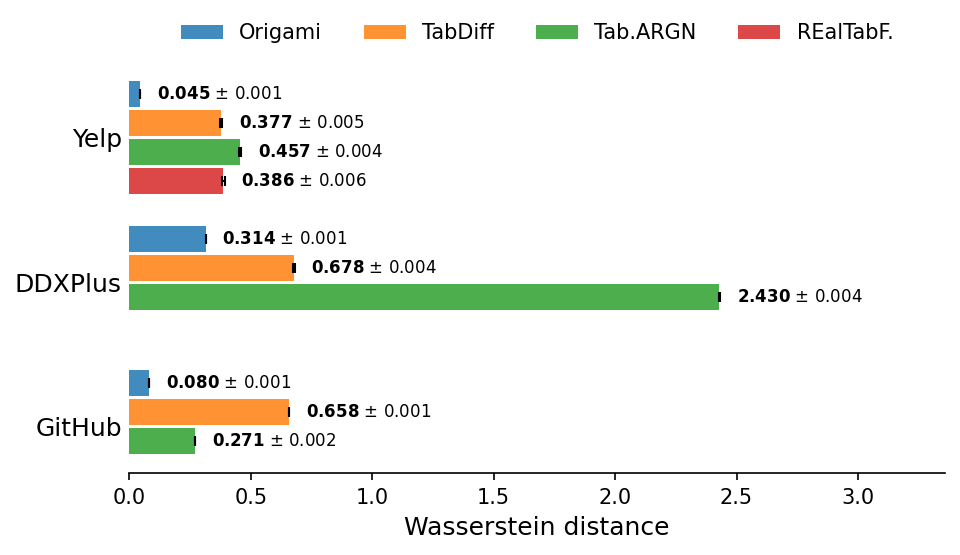

In [ ]:
# Grouped horizontal bars with stddev whiskers across synthetic samples.
# Bar length = mean Wasserstein across samples; whiskers = ± 1 sample stddev.

prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
COLORS = {name: prop_cycle[i] for i, name in enumerate(ALL_MODELS)}

dataset_names = list(DATASETS.keys())
n_groups = len(dataset_names)
n_models = len(ALL_MODELS)

group_width = 0.8
bar_width = group_width / n_models
y_centers = np.arange(n_groups)[::-1]  # first dataset on top

fig, ax = plt.subplots(figsize=(6.5, 3.8), dpi=150)

max_w1 = 0.0
for i, model in enumerate(ALL_MODELS):
    color = COLORS[model]
    # Negate so model index 0 lands at the top of its group.
    offset = -(i - (n_models - 1) / 2) * bar_width

    positions, means, stds, ns = [], [], [], []
    for j, ds in enumerate(dataset_names):
        if model not in DATASETS[ds]["models"]:
            continue
        w1s = np.array(w1_samples[ds][model])
        n = len(w1s)
        mean = w1s.mean()
        std = w1s.std(ddof=1) if n > 1 else 0.0
        positions.append(y_centers[j] + offset)
        means.append(mean)
        stds.append(std)
        ns.append(n)
        max_w1 = max(max_w1, mean + std)

    if not positions:
        continue
    bars = ax.barh(
        positions,
        means,
        xerr=stds,
        height=bar_width * 0.9,
        color=color,
        alpha=0.85,
        label=model,
        error_kw=dict(ecolor="black", elinewidth=1.0, capsize=2.5, capthick=1.0),
    )
    # Bold the mean via mathtext; stddev stays regular weight.
    labels = [
        rf"$\mathbf{{{m:.3f}}}$ ± {s:.3f}" if n_ > 1 else rf"$\mathbf{{{m:.3f}}}$"
        for m, s, n_ in zip(means, stds, ns, strict=True)
    ]
    ax.bar_label(bars, labels=labels, padding=8, fontsize=8)

ax.set_yticks(y_centers)
ax.set_yticklabels(dataset_names, fontsize=12)
ax.set_xlabel("Wasserstein distance", fontsize=12)
ax.set_xlim(0, max_w1 * 1.38)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.legend(fontsize=10, frameon=False, ncol=n_models, loc="lower center", bbox_to_anchor=(0.5, 1.0))
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.savefig("array_length_ablation.pdf", bbox_inches="tight", dpi=300)
plt.savefig("array_length_ablation.png", bbox_inches="tight", dpi=300, transparent=True)
plt.show()